<a href="https://colab.research.google.com/github/DhanadurgaLakshmi/AI-Engineering/blob/main/Day_9_CNN_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1401s 8us/step


In [ ]:
print("Training images:",x_train.shape)
print("Training labels:",y_train.shape)
print("Test images:",x_test.shape)
print("Test labels:",y_test.shape)


Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


In [ ]:
print("Image shape:",x_train[0].shape)
print("Label:",y_train[0])

Image shape: (32, 32, 3)
Label: [6]


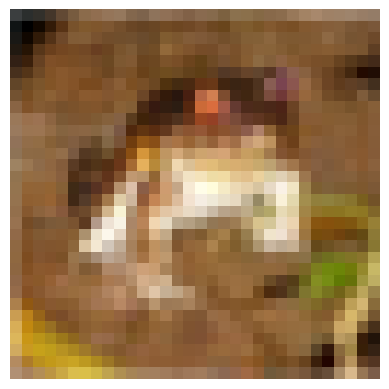

Label: 6


In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
plt.axis("off")
plt.show()
print("Label:",y_train[0][0])

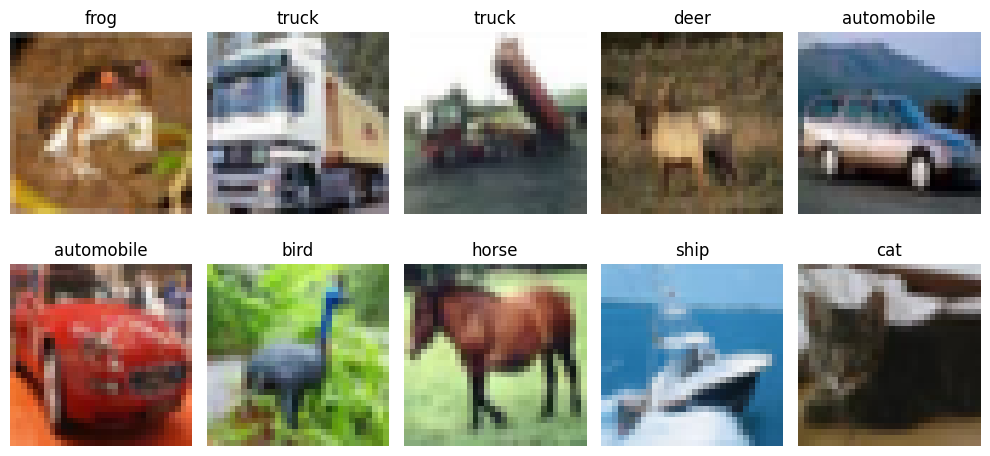

In [ ]:
class_names=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
print("Minimum pixel value:",x_train.min())
print("Maximum pixel value:",x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
import numpy as np
unique,counts=np.unique(y_train,return_counts=True)
for label,count in zip(unique,counts):
  print(class_names[label],":",count)

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


In [ ]:
print(x_train[0][0][0])

[0.23137255 0.24313726 0.24705882]


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Flatten,Dense

model=Sequential([
    Input(shape=(32,32,3)),
    Conv2D(32,(3,3),padding="same",activation="relu"),MaxPooling2D((2,2),strides=2)
,

                 Conv2D(32,(3,3),padding="same",activation="relu"),MaxPooling2D((2,2),strides=2),
                  Flatten(),
                  Dense(10,activation="softmax")
                  ])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,634 (119.66 KB)

 Trainable params: 30,634 (119.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
history=model.fit(x_train,y_train,epochs=10,batch_size=64,validation_split=0.1)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 91ms/step - accuracy: 0.4431 - loss: 1.5636 - val_accuracy: 0.5638 - val_loss: 1.2752
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.5715 - loss: 1.2263 - val_accuracy: 0.5766 - val_loss: 1.1785
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.6192 - loss: 1.0973 - val_accuracy: 0.6394 - val_loss: 1.0449
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 84ms/step - accuracy: 0.6500 - loss: 1.0137 - val_accuracy: 0.6474 - val_loss: 1.0220
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.6703 - loss: 0.9568 - val_accuracy: 0.6768 - val_loss: 0.9461
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.6859 - loss: 0.9144 - val_accuracy: 0.6768 - val_loss: 0.9530
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.6988 - loss: 0.8757 - val_accuracy: 0.6524 - val_loss: 0.9988
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.7079 - loss: 0.8452 - 

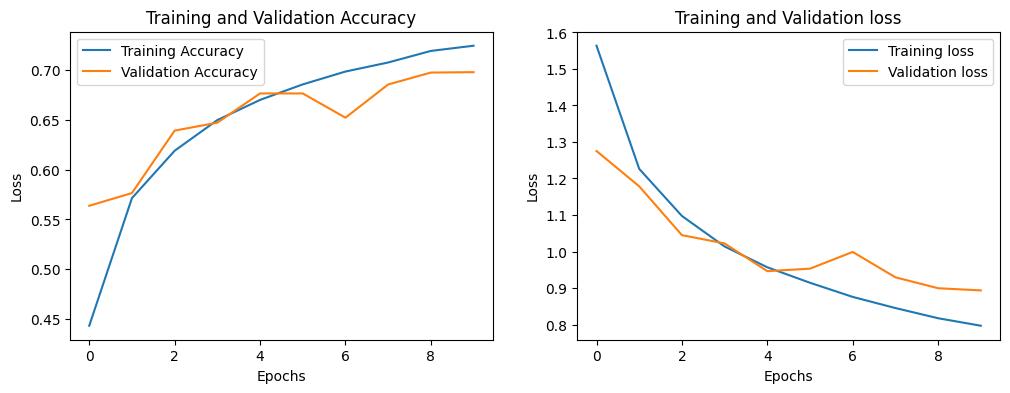

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.subplot(1,2,2)
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation loss")

plt.show()

In [ ]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6855 - loss: 0.9209
Test Loss: 0.9208715558052063
Test Accuracy: 0.6855000257492065


In [ ]:
import numpy as np
predictions=model.predict(x_test)
predicted_labels=np.argmax(predictions,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [ ]:
print("Prediction shape:",predictions.shape)
print("Predicted classes:",predicted_labels[:10])

Prediction shape: (10000, 10)
Predicted classes: [5 1 8 8 6 6 1 4 3 1]


In [ ]:
for i in range(10):
  actual=class_names[y_test[i][0]]
  predicted=class_names[predicted_labels[i]]
  print(f"image{i+1}: Actual={actual}, "
  f"Predicted={predicted}"
  )

image1: Actual=cat, Predicted=dog
image2: Actual=ship, Predicted=automobile
image3: Actual=ship, Predicted=ship
image4: Actual=airplane, Predicted=ship
image5: Actual=frog, Predicted=frog
image6: Actual=frog, Predicted=frog
image7: Actual=automobile, Predicted=automobile
image8: Actual=frog, Predicted=deer
image9: Actual=cat, Predicted=cat
image10: Actual=automobile, Predicted=automobile


In [ ]:
import numpy as np
actual_labels=y_test.flatten()
correct=predicted_labels==actual_labels
wrong_indices=np.where(~correct)[0]
print("Total test images:",len(actual_labels))
print("Total correct predictions:",np.sum(correct))
print("Wrong predictions:",len(wrong_indices))
print("Test accuracy:",np.mean(correct))

Total test images: 10000
Total correct predictions: 6855
Wrong predictions: 3145
Test accuracy: 0.6855


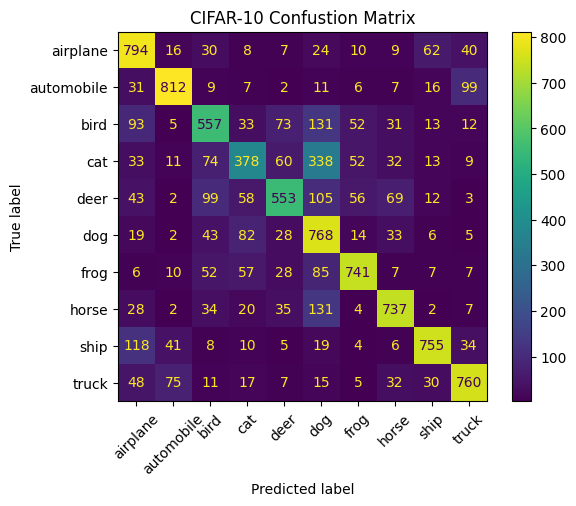

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(actual_labels,predicted_labels)
cm_display=ConfusionMatrixDisplay(cm,display_labels=class_names)
cm_display.plot(xticks_rotation=45)
plt.title("CIFAR-10 Confustion Matrix")
plt.show()

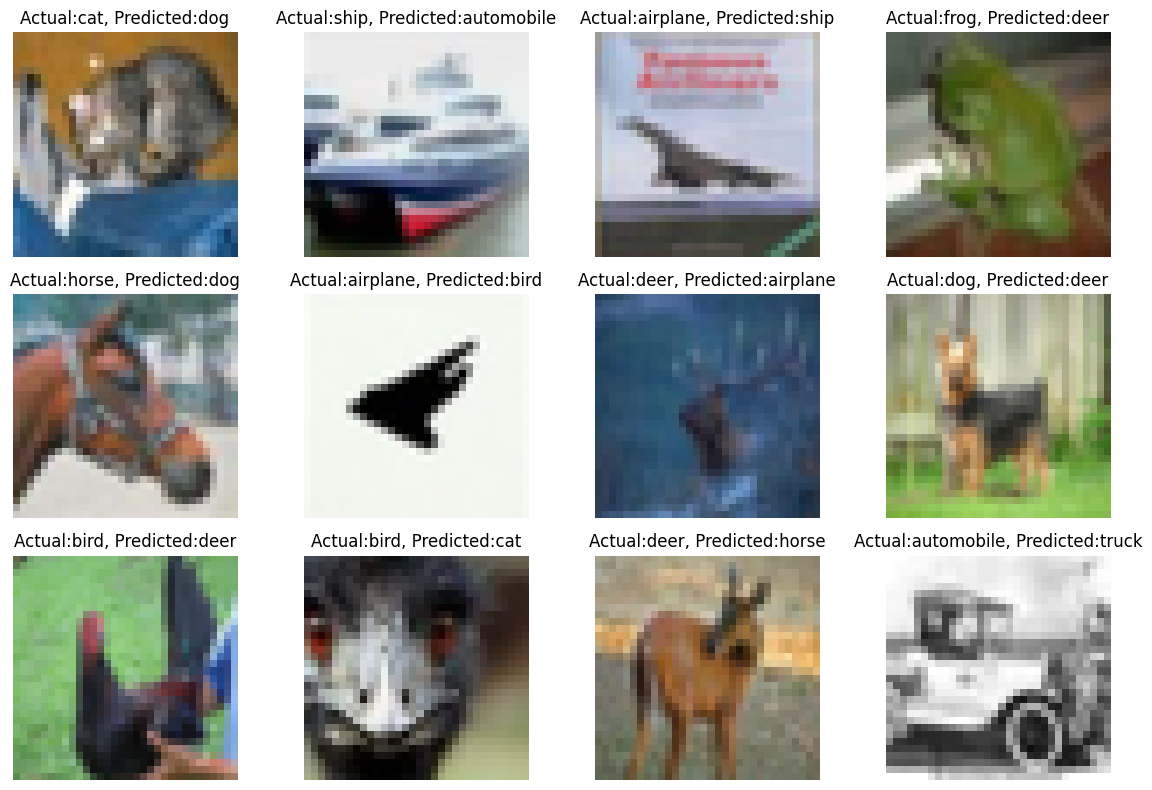

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))

for i in range(12):
  index=wrong_indices[i]
  plt.subplot(3,4,i+1)
  plt.imshow(x_test[index])
  actual=class_names[actual_labels[index]]
  predicted=class_names[predicted_labels[index]]
  plt.title(f"Actual:{actual}, Predicted:{predicted}")
  plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Conv2D,BatchNormalization,Dropout,MaxPooling2D,Flatten,Dense
import tensorflow as tf # Added to access tf.keras.layers.ReLU

improved_model=Sequential([
    Input(shape=(32,32,3)),
    Conv2D(32,(3,3),padding="same"),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),padding="same"),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])

In [ ]:
improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
improved_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"])

In [ ]:
improved_history=improved_model.fit(x_train,y_train,epochs=10,
                                    batch_size=64,validation_split=0.1)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 115s 159ms/step - accuracy: 0.2666 - loss: 1.9216 - val_accuracy: 0.3792 - val_loss: 1.6701
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 157ms/step - accuracy: 0.3437 - loss: 1.6792 - val_accuracy: 0.4690 - val_loss: 1.4617
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.3761 - loss: 1.5957 - val_accuracy: 0.4724 - val_loss: 1.4378
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.3963 - loss: 1.5527 - val_accuracy: 0.3994 - val_loss: 1.5228
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.4048 - loss: 1.5131 - val_accuracy: 0.4870 - val_loss: 1.3490
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 157ms/step - accuracy: 0.4188 - loss: 1.4939 - val_accuracy: 0.5020 - val_loss: 1.3501
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 113s 160ms/step - accuracy: 0.4245 - loss: 1.4686 - val_accuracy: 0.5670 - val_loss: 1.2355
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 113s 160ms/step - accuracy: 0.4379 -

In [ ]:
improved_test_loss,improved_test_accuracy=improved_model.evaluate(x_test,y_test)

print("improved Test Loss:",improved_test_loss)
print("improved Test Accuracy:",improved_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6011 - loss: 1.1850
improved Test Loss: 1.185015320777893
improved Test Accuracy: 0.6011000275611877


In [ ]:
print("Original CNN Test Accuracy:",test_accuracy)
print("Improved CNN Test Accuracy:",improved_test_accuracy)
difference=improved_test_accuracy-test_accuracy
print("Actual Difference:",difference)

Original CNN Test Accuracy: 0.6855000257492065
Improved CNN Test Accuracy: 0.6011000275611877
Actual Difference: -0.0843999981880188
